In [3]:
%cd /Users/victor/Documents/UrbanXYZ/DINO/GroundingDINO
from groundingdino.util.inference import load_model, load_image, predict, annotate

/Users/victor/Documents/UrbanXYZ/DINO/GroundingDINO


/Users/victor/Documents/UrbanXYZ/DINO/GroundingDINO/groundingdino/models/GroundingDINO/ms_deform_attn.py:31: UserWarning: Failed to load custom C++ ops. Running on CPU mode Only!
  warnings.warn("Failed to load custom C++ ops. Running on CPU mode Only!")


In [4]:

WEIGHTS_PATH = '/Users/victor/Documents/UrbanXYZ/DINO/weights/groundingdino_swint_ogc.pth'
CONFIG_PATH = '/Users/victor/Documents/UrbanXYZ/DINO/GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py'
model = load_model(CONFIG_PATH, WEIGHTS_PATH)

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3191.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


final text_encoder_type: bert-base-uncased


Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertModel: ['cls.seq_relationship.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.weight', 'cls.predictions.bias', 'cls.predictions.transform.dense.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [5]:
import os
import supervision as sv

In [6]:
IMAGE_PATH = "/Users/victor/Documents/UrbanXYZ/DINO/data/dog-3.jpeg"

TEXT_PROMPT = "car"
BOX_TRESHOLD = 0.4
TEXT_TRESHOLD = 0.65

image_source, image = load_image(IMAGE_PATH)

boxes, logits, phrases = predict(
    model=model, 
    image=image, 
    caption=TEXT_PROMPT, 
    box_threshold=BOX_TRESHOLD, 
    text_threshold=TEXT_TRESHOLD
)

annotated_frame = annotate(image_source=image_source, boxes=boxes, logits=logits, phrases=phrases)

%matplotlib inline  
sv.plot_image(annotated_frame, (16, 16))

AssertionError: Torch not compiled with CUDA enabled

In [ ]:
IMAGE_PATH = "/home/urbanxyz/zxx/landscape/cube/R0010335_Front.jpg"

TEXT_PROMPT = "Parking space marking"
BOX_TRESHOLD = 0.35
TEXT_TRESHOLD = 0.25

image_source, image = load_image(IMAGE_PATH)

boxes, logits, phrases = predict(
    model=model, 
    image=image, 
    caption=TEXT_PROMPT, 
    box_threshold=BOX_TRESHOLD, 
    text_threshold=TEXT_TRESHOLD)

annotated_frame = annotate(image_source=image_source, boxes=boxes, logits=logits, phrases=phrases)

%matplotlib inline  
sv.plot_image(annotated_frame, (16, 16))

In [2]:
from PIL import Image
import numpy as np
from scipy import ndimage
import matplotlib.pyplot as plt

In [18]:

image = Image.open("/home/urbanxyz/zxx/landscape/image/公园照片/图片色彩.jpg")
# 转换为RGB颜色空间
rgb_image = image.convert('RGB')

# 将RGB图像转换为numpy数组
rgb_array = np.array(rgb_image)

# 计算每个颜色的频率
colors, counts = np.unique(rgb_array.reshape(-1,3), axis=0, return_counts=True)

# 计算颜色的标准差
color_diff = np.diff(rgb_array.reshape(-1, 3), axis=0)
color_std = np.std(color_diff, axis=0)

# 计算颜色丰富度
colorfulness = np.sqrt(np.mean(np.square(counts/float(np.sum(counts))))) * np.std(np.linalg.norm(color_diff, axis=1))
colorfulness



0.008814038643791391

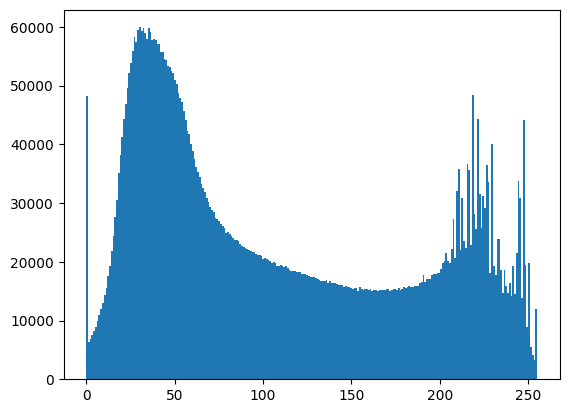

In [8]:
import cv2
import matplotlib.pyplot as plt

# 读取图片
img = cv2.imread("/home/urbanxyz/zxx/landscape/image/公园照片/图片色彩识别.jpg")

# 将图片转换为 RGB 模式
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 绘制色彩直方图
plt.hist(img.ravel(), bins=256, range=(0, 255))
plt.show()


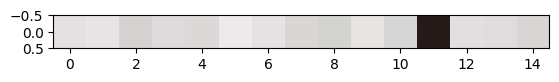

In [19]:
# 找到颜色分布最大的三种颜色
idx = np.argsort(-counts)[:15]
top_colors = colors[idx]

# 绘制图片中最主要的三种颜色
fig, ax = plt.subplots()
ax.imshow(np.array([top_colors]))
plt.show()